In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string
import spacy
from nltk import ngrams
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import random

In [84]:
speeches = pd.read_csv('speeches_processed.csv')

In [85]:
president_name_map = {
    "George Washington": ["George Washington", "Washington", "President Washington"],
    "John Adams": ["John Adams", "Adams", "President Adams"],
    "Thomas Jefferson": ["Thomas Jefferson", "Jefferson", "President Jefferson"],
    "James Madison": ["James Madison", "Madison", "President Madison"],
    "James Monroe": ["James Monroe", "Monroe", "President Monroe"],
    "John Quincy Adams": ["John Quincy Adams", "John Q. Adams", "Quincy Adams"],
    "Andrew Jackson": ["Andrew Jackson", "Jackson", "President Jackson"],
    "Martin Van Buren": ["Martin Van Buren", "Van Buren", "President Van Buren"],
    "William Henry Harrison": ["William Henry Harrison", "William H. Harrison", "W. H. Harrison", "General Harrison"],
    "John Tyler": ["John Tyler", "Tyler", "President Tyler"],
    "James K. Polk": ["James K. Polk", "James Polk", "Polk", "President Polk"],
    "Zachary Taylor": ["Zachary Taylor", "Taylor", "President Taylor", "General Taylor"],
    "Millard Fillmore": ["Millard Fillmore", "Fillmore", "President Fillmore"],
    "Franklin Pierce": ["Franklin Pierce", "Pierce", "President Pierce"],
    "James Buchanan": ["James Buchanan", "Buchanan", "President Buchanan"],
    "Abraham Lincoln": ["Abraham Lincoln", "Lincoln", "President Lincoln", "A. Lincoln"],
    "Andrew Johnson": ["Andrew Johnson", "Andrew Johnson", "President Johnson"],
    "Ulysses S. Grant": ["Ulysses S. Grant", "Ulysses Grant", "Grant", "President Grant", "General Grant"],
    "Rutherford B. Hayes": ["Rutherford B. Hayes", "Rutherford Hayes", "Hayes", "President Hayes"],
    "James A. Garfield": ["James A. Garfield", "James Garfield", "Garfield", "President Garfield"],
    "Chester A. Arthur": ["Chester A. Arthur", "Chester Arthur", "Arthur", "President Arthur"],
    "Grover Cleveland": ["Grover Cleveland", "Cleveland", "President Cleveland"],
    "Benjamin Harrison": ["Benjamin Harrison", "Harrison", "President Harrison"],
    "William McKinley": ["William McKinley", "McKinley", "President McKinley"],
    "Theodore Roosevelt": ["Theodore Roosevelt", "Teddy Roosevelt", "Roosevelt", "President Roosevelt", "T. Roosevelt"],
    "William Howard Taft": ["William Howard Taft", "William H. Taft", "Taft", "President Taft"],
    "Woodrow Wilson": ["Woodrow Wilson", "Wilson", "President Wilson"],
    "Warren G. Harding": ["Warren G. Harding", "Warren Harding", "Harding", "President Harding"],
    "Calvin Coolidge": ["Calvin Coolidge", "Coolidge", "President Coolidge"],
    "Herbert Hoover": ["Herbert Hoover", "Hoover", "President Hoover"],
    "Franklin D. Roosevelt": ["Franklin D. Roosevelt", "Franklin Roosevelt", "FDR", "President Roosevelt"],
    "Harry S. Truman": ["Harry S. Truman", "Harry Truman", "Truman", "President Truman"],
    "Dwight D. Eisenhower": ["Dwight D. Eisenhower", "Dwight Eisenhower", "Eisenhower", "President Eisenhower", "Ike"],
    "John F. Kennedy": ["John F. Kennedy", "John Kennedy", "JFK", "President Kennedy"],
    "Lyndon B. Johnson": ["Lyndon B. Johnson", "Lyndon Johnson", "LBJ", "President Johnson"],
    "Richard Nixon": ["Richard Nixon", "Nixon", "President Nixon"],
    "Gerald Ford": ["Gerald Ford", "Ford", "President Ford"],
    "Jimmy Carter": ["Jimmy Carter", "James Carter", "Carter", "President Carter"],
    "Ronald Reagan": ["Ronald Reagan", "Reagan", "President Reagan"],
    "George H. W. Bush": ["George H. W. Bush", "George H.W. Bush", "George Bush", "President Bush", "Bush Senior"],
    "Bill Clinton": ["Bill Clinton", "William J. Clinton", "Clinton", "President Clinton"],
    "George W. Bush": ["George W. Bush", "George Bush", "President Bush", "Bush Junior"],
    "Barack Obama": ["Barack Obama", "Obama", "President Obama"],
    "Joe Biden": ["Joe Biden", "Joseph Biden", "Biden", "President Biden", "Joseph R. Biden"],
    "Donald Trump": ["Donald Trump", "Donald J. Trump", "Trump", "President Trump"]
}

In [86]:
alias_to_official_name = {}
for official_name, aliases in president_name_map.items():
    for alias in aliases:
        # Lowercase the key for case-insensitive matching safety
        alias_to_official_name[alias.lower()] = official_name

# alias_to_official_name

import ast

# Safely evaluate the string representation of a list back into a real list object
speeches['entities'] = speeches['entities'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)

In [87]:
type(speeches['entities'].iloc[6])

list

In [88]:
# 2. Update the function to map aliases back to the master key
def get_standardized_presidents(extracted_names, mapping_dict):
    standardized_list = []
    #print(extracted_names) # extracted names is a list 
    for name in extracted_names:
        name_lower = name.lower()
        if name_lower in mapping_dict.keys():
            # Grab the official name instead of the raw text chunk
            official = mapping_dict[name_lower]
            standardized_list.append(official)
            
    # Use set() and list() to remove duplicates if a name is mentioned multiple times in one speech
    return list(set(standardized_list))


speeches['matched_presidents'] = speeches['entities'].apply(
    lambda x: get_standardized_presidents(x, alias_to_official_name)
)

In [89]:
speeches.head(50)

,President,Party,from,until,Vice President,title,date,info,speech,entities,matched_presidents
0,Donald Trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020-01-08 00:00:00,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...,"[Qasem Soleimani, Soleimani, Soleimani, Al-Bag...",[]
1,Donald Trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020-01-03 00:00:00,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ...","[Qasem Soleimani, Soleimani, Soleimani, Soleim...",[]
2,Donald Trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019-10-27 00:00:00,President Donald Trump announces the death of ...,"Last night, the United States brought the worl...","[Abu Bakr al-Baghdadi, U. S. Special Operatio...",[]
3,Donald Trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019-09-25 00:00:00,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...,"[Larry Kudlow, Larry, Larry, Larry Kudlow, Kev...","[Donald Trump, Barack Obama, Joe Biden]"
4,Donald Trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019-09-24 00:00:00,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...,"[U. S. -Mexico-Canada Agreement, Abe, Boris Jo...",[]
5,Donald Trump,Republican,2017,2021,1.0,"February 15, 2019: Speech Declaring a National...",2019-02-15 00:00:00,President Donald Trump declares a national eme...,"THE PRESIDENT: Thank you very much, everybody...","[Xi, Brexit, Kim, Kim, Kim, Nancy, Chuck, Ange...","[Donald Trump, Barack Obama]"
6,Donald Trump,Republican,2017,2021,1.0,"February 5, 2019: State of the Union Address",2019-02-05 00:00:00,"In his second State of the Union Address, Pres...","Madam Speaker, Mr. Vice President, Members of...","[Dwight D. Eisenhower, Joseph Reilly, Sergean...",[James Madison]
7,Donald Trump,Republican,2017,2021,1.0,"January 19, 2019: Remarks about the US Souther...",2019-01-19 00:00:00,President Donald Trump speaks about what he se...,"THE PRESIDENT: Just a short time ago, I had th...","[Heroin, Angel, Straightforward, Mitch McConnell]",[]
8,Donald Trump,Republican,2017,2021,1.0,"September 25, 2018: Address at the 73rd Sessio...",2018-09-25 00:00:00,President Donald Trump addresses the General A...,"THE PRESIDENT: Madam President, Mr. Secretary...","[Laughter, Kim Jong Un, Kim, Moon, Abe, Xi, As...",[James Monroe]
9,Donald Trump,Republican,2017,2021,1.0,"July 24, 2018: Speech at the Veterans of Forei...",2018-07-24 00:00:00,President Trump addresses American veterans fr...,"THE PRESIDENT: Thank you, Lee. Thank you, Lee...","[Lee, Lee, Harman, George Brett, George, Bob W...",[Donald Trump]


In [90]:
president1 = []
president2 = []

def grab_prez_names(row):
    # Check if the list exists and is not empty
    if isinstance(row['matched_presidents'], list) and len(row['matched_presidents']) > 0:
        for found in row['matched_presidents']: 
            # Append the speaker (the president who gave the speech)
            president1.append(row['President'])
            # Append the mentioned president
            president2.append(found)

speeches.apply(lambda x: grab_prez_names(x), axis =1)

0      None
1      None
2      None
3      None
4      None
       ... 
990    None
991    None
992    None
993    None
994    None
Length: 995, dtype: object

In [93]:
presidential_references_df = pd.DataFrame(data = {'President1': president1, 'President2': president2}) 
values = presidential_references_df.value_counts()
values = pd.DataFrame(values).sort_values(['President1', 'count'], ascending = False).reset_index()

In [94]:
values_select = values[values['President1'] != values['President2']]
values_select.head()

,President1,President2,count
0,Zachary Taylor,James K. Polk,1
1,Zachary Taylor,Andrew Jackson,1
3,Woodrow Wilson,James Monroe,2
4,Woodrow Wilson,George Washington,1
5,William Taft,James Monroe,2


In [95]:
import networkx as nx
G = nx.from_pandas_edgelist(
    values_select, 
    source='President1', 
    target='President2', 
    edge_attr='count',      # Stores the count as an edge property
    create_using=nx.DiGraph()
)

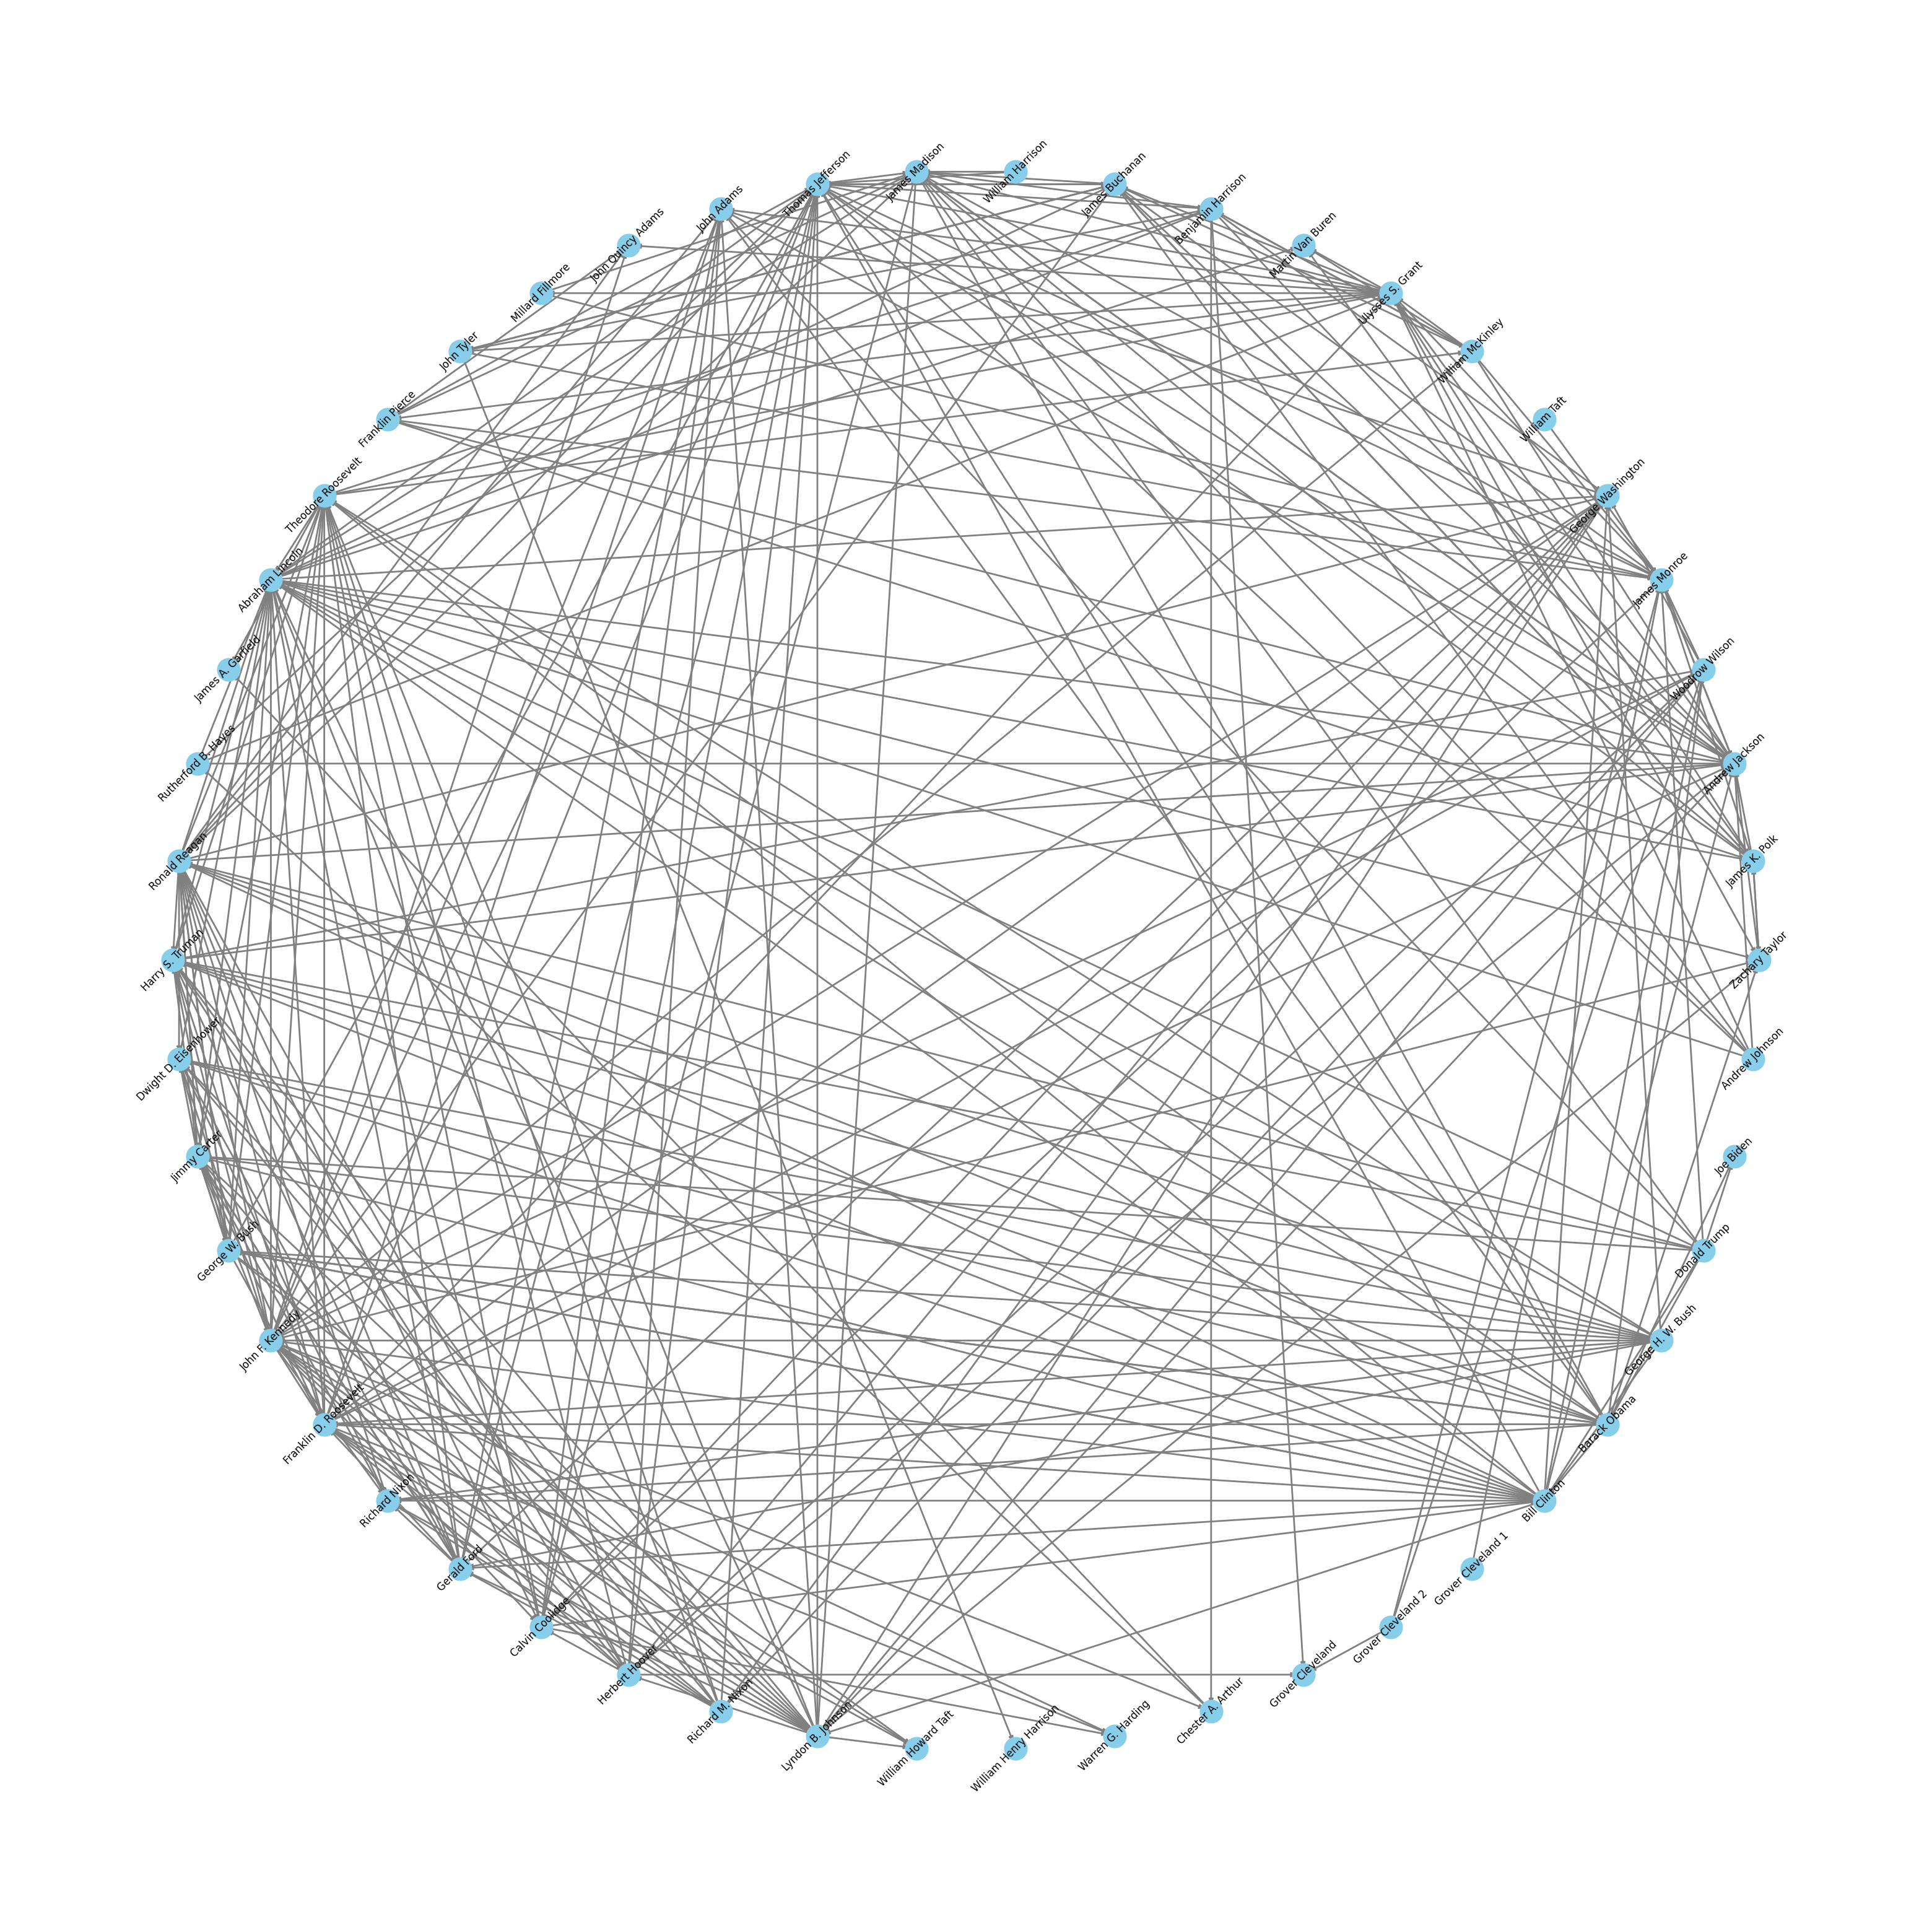

In [101]:
fig = plt.figure(figsize = (40, 40))
# nx.draw(G, with_labels = True)

pos = nx.circular_layout(G)

# Draw the nodes and edges separately with custom styling
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
# nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')
labels = nx.draw_networkx_labels(G, pos, font_size=12)
for node, text in labels.items():
    text.set_rotation(45)
    
plt.axis('off') # Hide the axes
plt.show()

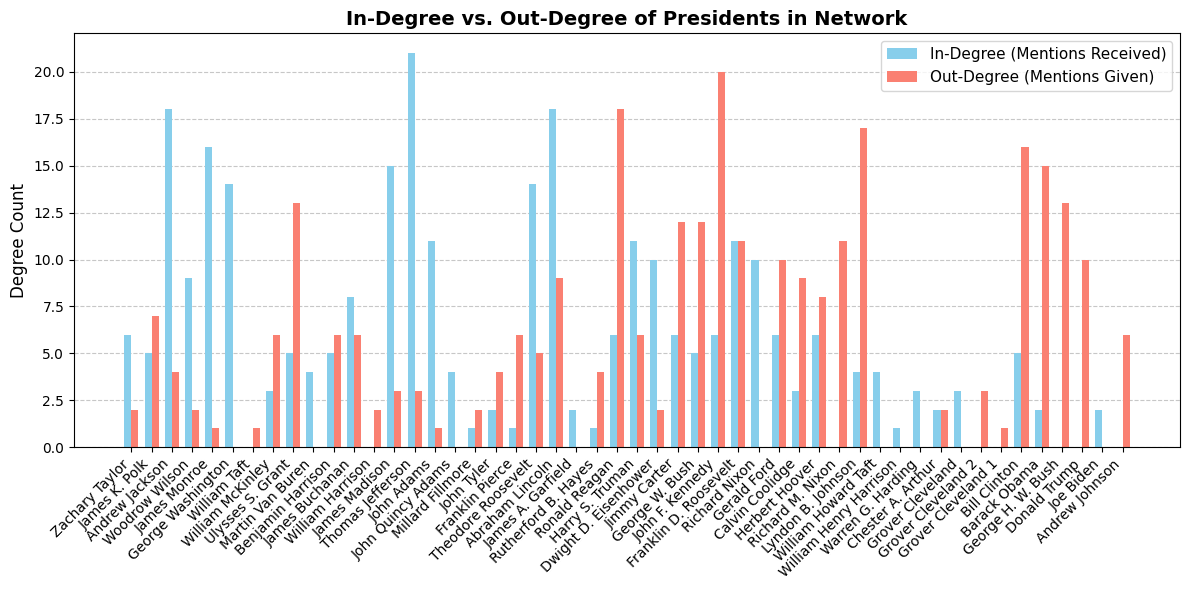

In [97]:
in_degree_small = G.in_degree
out_degree_small = G.out_degree

def plot_in_out_degrees(G):
    # 1. Extract the degrees as dictionaries
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # 2. Ensure both lists follow the exact same node order
    nodes = list(G.nodes())
    in_values = [in_degrees[node] for node in nodes]
    out_values = [out_degrees[node] for node in nodes]
    
    # 3. Set up the positions for a grouped bar chart
    x = np.arange(len(nodes))  # Label locations
    width = 0.35               # Width of each individual bar
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 4. Plot both sets of bars side-by-side
    bars_in = ax.bar(x - width/2, in_values, width, label='In-Degree (Mentions Received)', color='skyblue')
    bars_out = ax.bar(x + width/2, out_values, width, label='Out-Degree (Mentions Given)', color='salmon')
    
    # 5. Make the plot look clean and readable
    ax.set_ylabel('Degree Count', fontsize=12)
    ax.set_title('In-Degree vs. Out-Degree of Presidents in Network', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(node) for node in nodes], rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    
    # Optional: Add gridlines behind the bars for better readability
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Call the function with your graph object
plot_in_out_degrees(G)